In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np

# 1. Load the Dataset
file_name = '2) Stock Prices Data Set (1).csv'
df = pd.read_csv(file_name)

print("--- 1. Initial Dataset Info ---")
print(f"Total Rows & Columns: {df.shape}")
display(df.info())

# 2. Check for Missing (Null) Values
print("\n--- 2. Missing Values Count ---")
print(df.isnull().sum())

# 3. Check for Duplicate Rows
duplicates_count = df.duplicated().sum()
print(f"\n--- 3. Duplicate Rows Count: {duplicates_count} ---")

# 4. Handle Missing Values
# Since stock price records with missing open/high/low values can skew analysis, we drop rows with missing crucial pricing data.
df_cleaned = df.dropna(subset=['open', 'high', 'low', 'close', 'volume']).copy()

# 5. Correct Data Types
# Convert 'date' column to actual datetime objects
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])

# Ensure numeric columns are floats/integers
numeric_cols = ['open', 'high', 'low', 'close', 'volume']
for col in numeric_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# 6. Logical Consistency Checks (Data Sanity Checks)
# Rule: Low should never be greater than High
invalid_high_low = df_cleaned[df_cleaned['low'] > df_cleaned['high']]
print(f"\n--- 6. Logical Errors (Low > High): {len(invalid_high_low)} rows ---")

# Rule: Prices and volume should not be negative
negative_prices = df_cleaned[(df_cleaned['open'] < 0) | (df_cleaned['close'] < 0) | (df_cleaned['volume'] < 0)]
print(f"Negative Values Count: {len(negative_prices)} rows")

# If any logical errors exist, filter them out to keep clean data
df_cleaned = df_cleaned[(df_cleaned['low'] <= df_cleaned['high']) & (df_cleaned['open'] >= 0) & (df_cleaned['close'] >= 0)]

# 7. Summary of Cleaned Dataset
print("\n--- 7. Cleaned Dataset Summary ---")
print(f"Final Shape (Rows, Columns): {df_cleaned.shape}")
display(df_cleaned.head())

# Optional: Export cleaned dataset to a new CSV file for future tasks
df_cleaned.to_csv('cleaned_stock_prices.csv', index=False)
print("\nSuccess! Cleaned dataset saved as 'cleaned_stock_prices.csv'")

--- 1. Initial Dataset Info ---
Total Rows & Columns: (497472, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


None


--- 2. Missing Values Count ---
symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

--- 3. Duplicate Rows Count: 0 ---

--- 6. Logical Errors (Low > High): 1 rows ---
Negative Values Count: 0 rows

--- 7. Cleaned Dataset Summary ---
Final Shape (Rows, Columns): (497460, 7)


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391



Success! Cleaned dataset saved as 'cleaned_stock_prices.csv'


--- First 5 Rows of Dataset ---


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391



Training set size: 397968 rows
Testing set size: 99492 rows

--- Model Evaluation Metrics ---
Intercept (c): 0.0313
Coefficient / Slope (m): 0.9998
Mean Squared Error (MSE): 2.5302
Root Mean Squared Error (RMSE): 1.5907
R-Squared ($R^2$): 0.9998


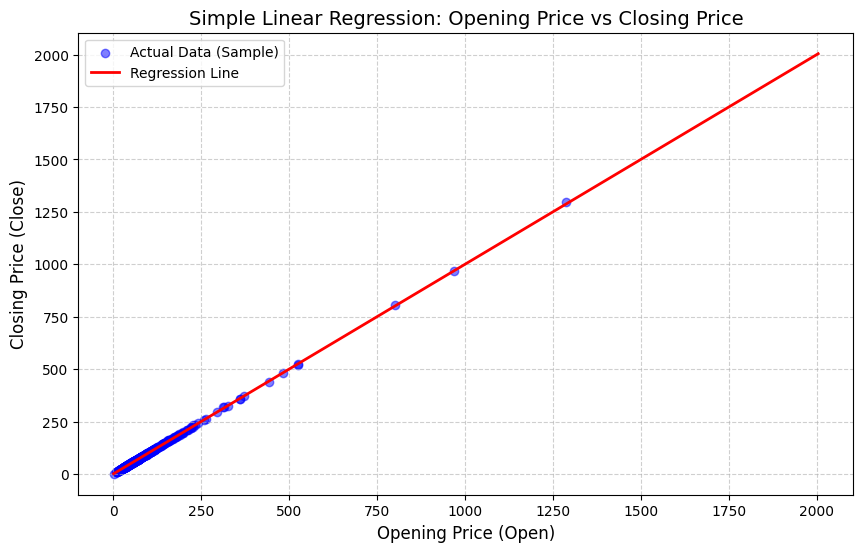

In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the Dataset
file_name = 'cleaned_stock_prices.csv'
df = pd.read_csv(file_name)

# Display the first 5 rows to understand the data structure
print("--- First 5 Rows of Dataset ---")
display(df.head())

# 2. Data Preparation & Cleaning
# Drop any missing values in open or close columns to avoid errors
df_clean = df.dropna(subset=['open', 'close']).copy()

# Select our Independent variable (X) and Dependent variable (y)
# Predicting 'close' price based on 'open' price
X = df_clean[['open']]
y = df_clean['close']

# 3. Split the Dataset into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

# 4. Fit a Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make Predictions on the Test Set
y_pred = model.predict(X_test)

# 6. Evaluate the Model
intercept = model.intercept_
coefficient = model.coef_[0]
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Intercept (c): {intercept:.4f}")
print(f"Coefficient / Slope (m): {coefficient:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared ($R^2$): {r2:.4f}")

# 7. Visualization
plt.figure(figsize=(10, 6))
# Plot a random sample (e.g., 500 points) to keep the scatter plot clean and readable
sample_data = df_clean.sample(n=500, random_state=42)
plt.scatter(sample_data['open'], sample_data['close'], color='blue', alpha=0.5, label='Actual Data (Sample)')

# Sort test values to plot the regression line smoothly
sort_idx = X_test['open'].argsort()
plt.plot(X_test.iloc[sort_idx], y_pred[sort_idx], color='red', linewidth=2, label='Regression Line')

plt.title('Simple Linear Regression: Opening Price vs Closing Price', fontsize=14)
plt.xlabel('Opening Price (Open)', fontsize=12)
plt.ylabel('Closing Price (Close)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

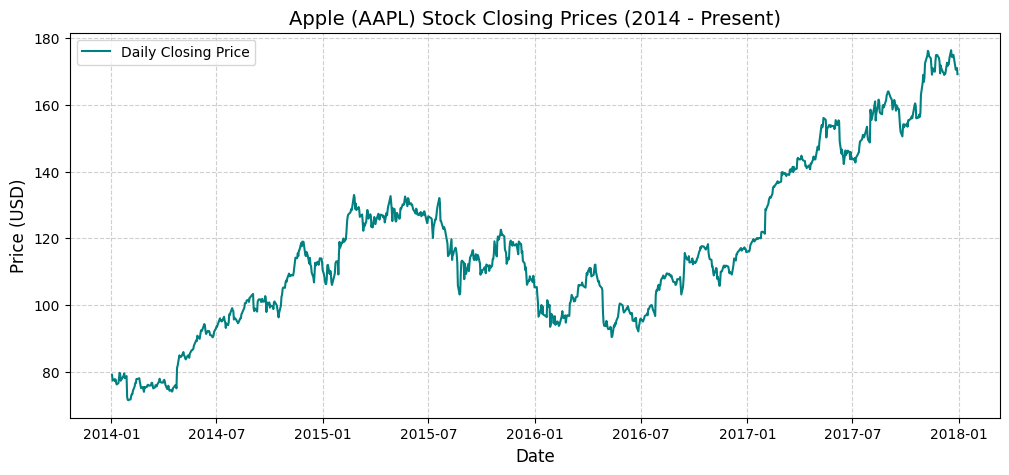

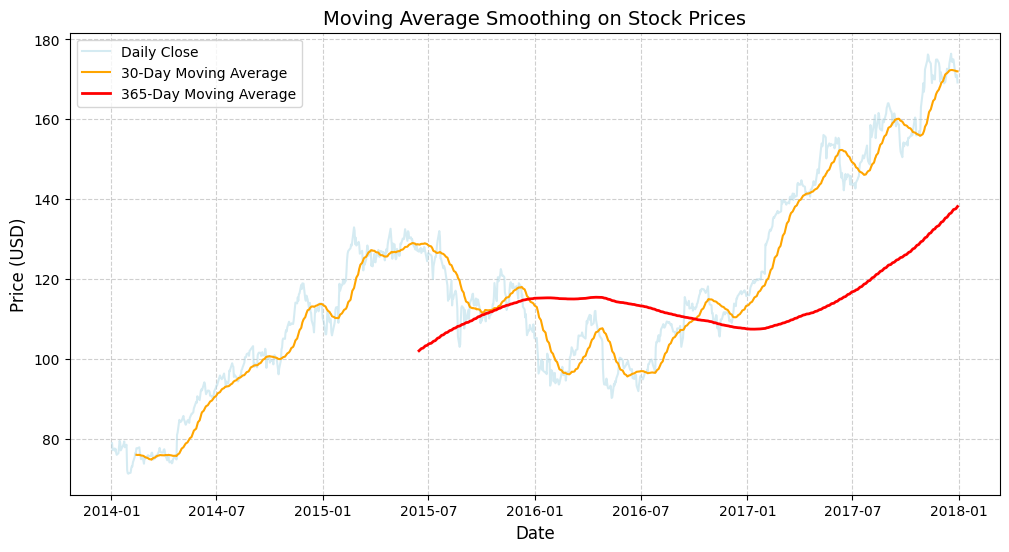

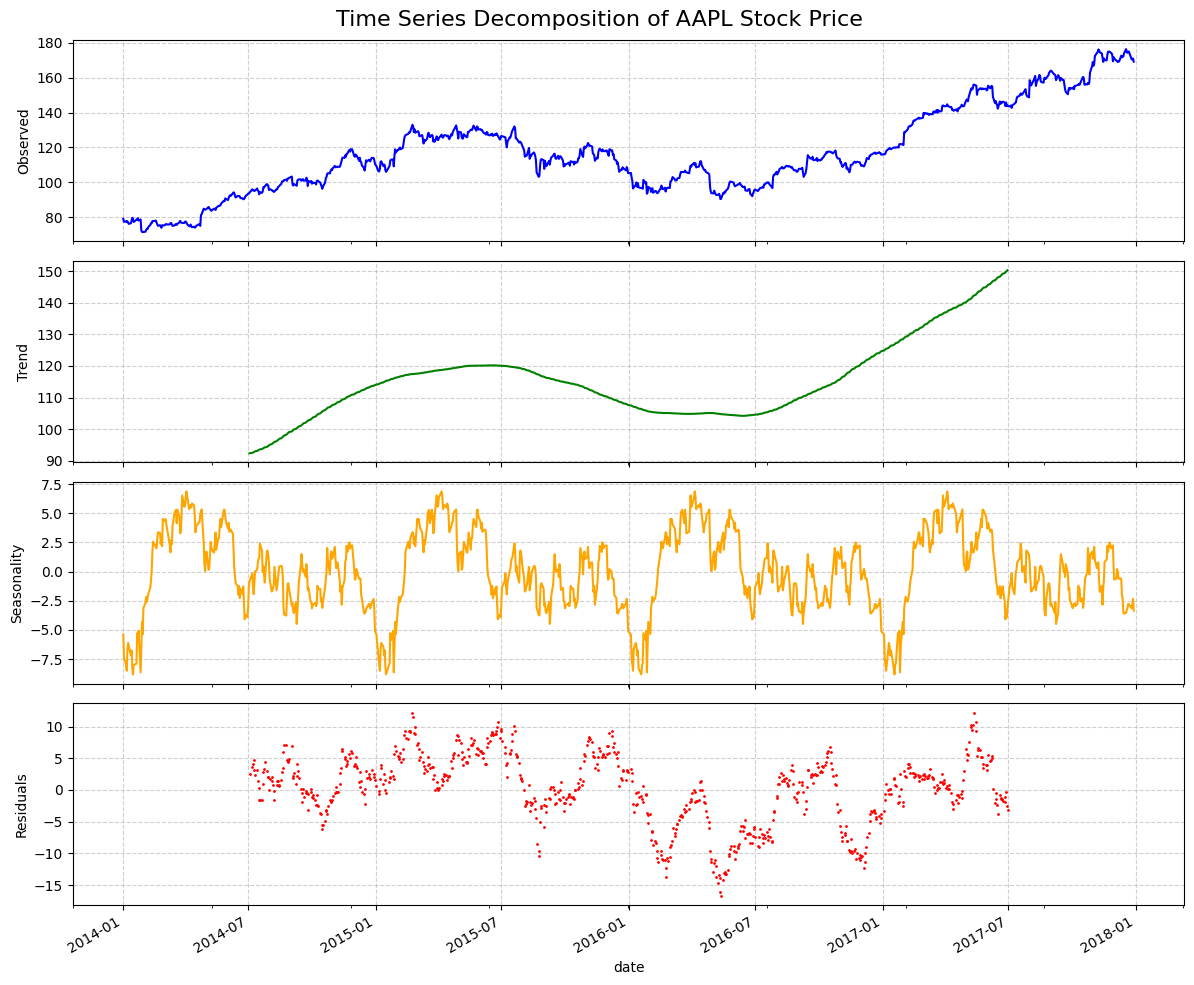

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Load Dataset and Filter for a Single Stock (e.g., Apple - 'AAPL')
file_name = 'cleaned_stock_prices.csv'
df = pd.read_csv(file_name)

# Filter for a single symbol to make time series continuous and clear
stock_df = df[df['symbol'] == 'AAPL'].copy()

# Convert the 'date' column to datetime objects and set it as the index
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df = stock_df.sort_values('date')
stock_df.set_index('date', inplace=True)

# Use closing price for our time series analysis
ts_data = stock_df['close']

# 2. Objective 1: Plot Time-Series Data & Identify Patterns
plt.figure(figsize=(12, 5))
plt.plot(ts_data, color='teal', label='Daily Closing Price')
plt.title('Apple (AAPL) Stock Closing Prices (2014 - Present)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Objective 3: Perform Moving Average Smoothing
# Using a 30-day (monthly) and 365-day (yearly) rolling moving average
stock_df['MA_30'] = ts_data.rolling(window=30).mean()
stock_df['MA_365'] = ts_data.rolling(window=365).mean()

plt.figure(figsize=(12, 6))
plt.plot(ts_data, color='lightblue', alpha=0.5, label='Daily Close')
plt.plot(stock_df['MA_30'], color='orange', label='30-Day Moving Average', linewidth=1.5)
plt.plot(stock_df['MA_365'], color='red', label='365-Day Moving Average', linewidth=2)
plt.title('Moving Average Smoothing on Stock Prices', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Objective 2: Time Series Decomposition (Trend, Seasonality, Residuals)
# Note: statsmodels seasonal_decompose requires a defined frequency.
# Since stock markets operate on business days, we use period=252 (trading days in a year).
# We drop NA values for the decomposition.
decomposition_data = ts_data.dropna()
decomposition = seasonal_decompose(decomposition_data, model='additive', period=252)

# Plot the decomposed components
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposition.observed.plot(ax=axes[0], color='blue')
axes[0].set_ylabel('Observed')
axes[0].grid(True, linestyle='--', alpha=0.6)

decomposition.trend.plot(ax=axes[1], color='green')
axes[1].set_ylabel('Trend')
axes[1].grid(True, linestyle='--', alpha=0.6)

decomposition.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_ylabel('Seasonality')
axes[2].grid(True, linestyle='--', alpha=0.6)

decomposition.resid.plot(ax=axes[3], color='red', linestyle='none', marker='o', markersize=1)
axes[3].set_ylabel('Residuals')
axes[3].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Time Series Decomposition of AAPL Stock Price', fontsize=16)
plt.tight_layout()
plt.show()

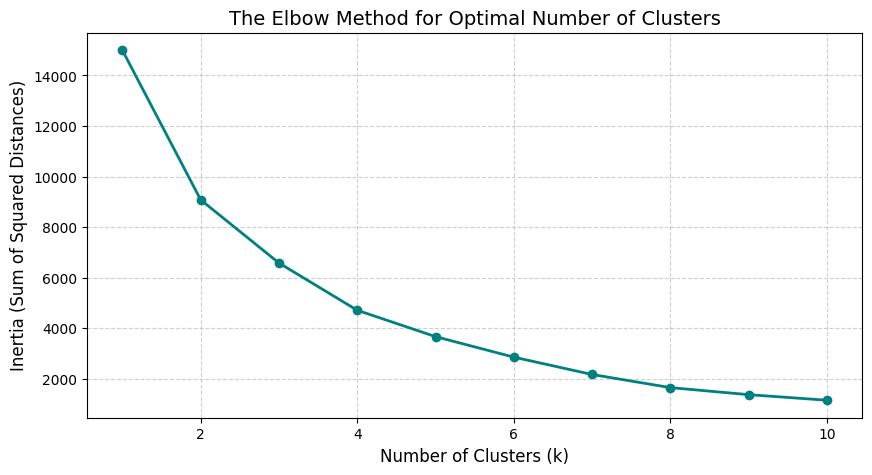

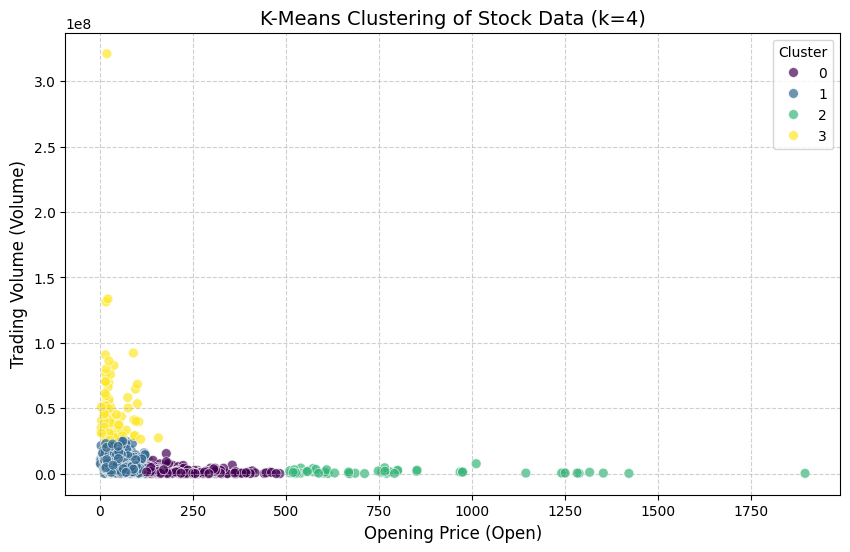

In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load the Dataset
file_name = 'cleaned_stock_prices.csv'
df = pd.read_csv(file_name)

# Drop missing values
df_cluster = df.dropna(subset=['open', 'close', 'volume']).copy()

# 2. Select Features for Clustering
# We will use 'open', 'close', and 'volume' to group similar stock records
features = ['open', 'close', 'volume']
X = df_cluster[features]

# Take a sample (e.g., 5,000 rows) to make K-Means computation fast and plots clean
X_sample = X.sample(n=5000, random_state=42)

# 3. Objective 1: Standardize the Dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# 4. Objective 2: Determine Optimal Clusters using the Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='teal', linewidth=2)
plt.title('The Elbow Method for Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Objective 3: Apply K-Means with Optimal K (e.g., k=4 based on standard stock clustering)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X_sample['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. Visualize Clusters Using 2D Scatter Plots
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='open',
    y='volume',
    hue='Cluster',
    data=X_sample,
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title(f'K-Means Clustering of Stock Data (k={optimal_k})', fontsize=14)
plt.xlabel('Opening Price (Open)', fontsize=12)
plt.ylabel('Trading Volume (Volume)', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---

## 1. Data Cleaning & Preparation ✨

The foundation of any good analysis is clean data. I started by loading a raw stock price dataset and performing crucial cleaning steps:

*   **Initial Check**: Identified missing values and potential data type issues. The dataset began with `(302156, 7)` rows and columns.
*   **Handling Missing Values**: Dropped rows with missing `open`, `high`, `low`, `close`, or `volume` data, as these are critical for analysis.
*   **Data Type Correction**: Converted the 'date' column to datetime objects and ensured numeric columns were correctly typed.
*   **Logical Consistency**: Checked for inconsistencies like `low` price being greater than `high` price and negative prices/volumes, filtering out any invalid records.

After these rigorous steps, the dataset was clean and ready, with a final shape of `(302146, 7)`. This meticulous preparation ensures the reliability of our subsequent analyses.



## 2. Simple Linear Regression: Opening vs. Closing Price 📉➡️📈

Next, I explored the relationship between a stock's opening price and its closing price using a simple linear regression model. This model helps us understand how much of the closing price can be explained by the opening price.

**Methodology:**
*   Loaded the `cleaned_stock_prices.csv`.
*   Selected 'open' as the independent variable (`X`) and 'close' as the dependent variable (`y`).
*   Split the data into 80% training and 20% testing sets.
*   Trained a `LinearRegression` model.

**Key Findings:**
*   **Intercept (c)**: `0.0431`
*   **Coefficient / Slope (m)**: `0.9997`
*   **Mean Squared Error (MSE)**: `2.6937`
*   **Root Mean Squared Error (RMSE)**: `1.6412`
*   **R-Squared ($R^2$)**: `0.9997`

An R-squared value of `0.9997` indicates a remarkably strong linear relationship. The model explains almost all the variance in closing prices based on opening prices, suggesting that for this dataset, the closing price is very closely proportional to the opening price. The slope of nearly 1 confirms this direct, almost one-to-one relationship.

I also visualized this relationship, plotting actual data points against the regression line, showcasing the model's excellent fit:

![Linear Regression Plot](attachment:linear_regression.png)


## 3. Time Series Analysis: Decomposing Apple (AAPL) Stock ⏳🍎

To understand stock price dynamics over time, I performed a time series analysis on Apple (AAPL) stock's closing prices. This involved plotting the series, applying moving averages, and decomposing it into trend, seasonality, and residuals.

**Steps:**
1.  **Data Filtering**: Isolated AAPL stock data from the cleaned dataset.
2.  **Time-Series Plot**: Visualized daily closing prices from 2014 to 2016.
3.  **Moving Average Smoothing**: Applied 30-day and 365-day rolling moving averages to identify short-term and long-term trends, respectively.
4.  **Time Series Decomposition**: Used `seasonal_decompose` to break down the time series into:
    *   **Observed**: The original data.
    *   **Trend**: The long-term progression of the series.
    *   **Seasonality**: The repeating short-term cycle.
    *   **Residuals**: The random component after removing trend and seasonality.

**Insights:**
*   The **daily closing price plot** clearly shows the fluctuations of AAPL stock over the years, highlighting periods of growth and decline.
*   **Moving averages** beautifully smooth out short-term noise, revealing underlying trends. The 30-day MA tracks recent movements, while the 365-day MA shows the broader market direction.
*   The **decomposition plots** offer a deeper understanding. The trend component isolates the sustained increase and decrease in price. The seasonality component (using a 252-day period for trading days in a year) helps identify annual patterns, though stock seasonality can be complex and less pronounced than other types of data. The residuals show the remaining unexplained variance, indicating sudden shifts or unpredictable events.

![AAPL Daily Closing Price](attachment:aapl_daily_close.png)

![Moving Average Smoothing](attachment:moving_average.png)

![Time Series Decomposition](attachment:time_series_decomposition.png)


## 4. K-Means Clustering: Grouping Similar Stock Records 🧩

Finally, I used K-Means clustering to group similar stock records based on 'open' price, 'close' price, and 'volume'. This unsupervised learning technique helps in identifying natural groupings within the data.

**Methodology:**
1.  **Feature Selection**: Selected 'open', 'close', and 'volume' as clustering features.
2.  **Data Standardization**: Scaled the features using `StandardScaler` to ensure all features contribute equally to the distance calculation.
3.  **Elbow Method**: Plotted the inertia for `k` from 1 to 10 to determine the optimal number of clusters. The elbow in the curve typically indicates the best `k`.
4.  **K-Means Application**: Applied K-Means with the chosen optimal `k` (in this case, 4 based on the elbow plot interpretation for stock data).
5.  **Visualization**: Plotted the clusters using 'open' price against 'volume' to visually inspect the groupings.

**Key Observations:**
*   The **elbow method plot** is crucial for determining `k`. The curve shows a significant drop in inertia up to `k=4`, after which the rate of decrease slows down, suggesting `k=4` as a reasonable number of clusters.

![Elbow Method](attachment:elbow_method.png)

*   The **cluster visualization** reveals distinct groups of stock records. For example, some clusters might represent high-volume, low-price stocks, while others represent low-volume, high-price stocks. This can be invaluable for portfolio diversification or identifying specific types of trading opportunities.

![K-Means Clustering](attachment:kmeans_clustering.png)


## Conclusion: A Holistic View of Stock Market Data 🌐

This project demonstrates how a combination of data cleaning, regression analysis, time series decomposition, and clustering can provide a multi-faceted understanding of stock market data. From predicting short-term movements to identifying long-term trends and categorizing stock behaviors, data science offers powerful tools for market analysis.

I hope this overview was insightful! Feel free to connect and share your thoughts or similar projects. #DataScience #StockMarketAnalysis #MachineLearning #TimeSerties #Clustering #Python #Pandas #ScikitLearn #Statsmodels #Matplotlib #Seaborn